In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Load the raw dataset
data = pd.read_csv('Nepali_Treking.csv')

# Display initial data information
print("Initial Data:")
print(data.head())


Initial Data:
   Unnamed: 0                                 Trek              Cost  \
0           0               Everest Base Camp Trek  \n$1,420     USD   
1           1         Everest Base Camp Short Trek  \n$1,295     USD   
2           2  Everest Base Camp Heli Shuttle Trek       \n$2000 USD   
3           3          Everest Base Camp Heli Trek  \n$3,300     USD   
4           4   Everest Base Camp Trek for Seniors  \n$1,800     USD   

       Time Trip Grade Max Altitude      Accomodation  \
0   16 Days   Moderate       5545 m  Hotel/Guesthouse   
1   14 Days   Moderate       5545 m  Hotel/Guesthouse   
2   12 Days   Moderate       5545 m  Hotel/Guesthouse   
3   11 Days   Moderate       5545 m  Hotel/Guesthouse   
4   20 Days   Moderate       5545 m  Hotel/Guesthouse   

           Best Travel Time Date of Travel         Sex  ...  GraduateOrNot  \
0  March - May & Sept - Dec      9/13/2022  Non-Binary  ...            Yes   
1  March - May & Sept - Dec       9/4/2021      Female

In [ ]:
# Check for missing values
print("\nMissing Values Before Imputation:")
print(data.isnull().sum())

# Convert column names to lowercase and replace spaces with underscores
data.columns = data.columns.str.lower().str.replace(' ', '_').str.replace(r'[^a-zA-Z0-9_]', '')

# Display cleaned column names
print("Column names after cleaning:")
print(data.columns)



Missing Values Before Imputation:
Unnamed: 0             0
Trek                   0
Cost                   0
Time                   0
Trip Grade             0
Max Altitude           0
Accomodation           0
Best Travel Time       0
Date of Travel         0
Sex                    0
Age                    0
Employment Type        0
GraduateOrNot          0
AnnualIncome           0
FamilyMembers          0
ChronicDiseases        0
FrequentFlyer          0
EverTravelledAbroad    0
TravelInsurance        0
Year                   0
Regional code          0
Country                0
dtype: int64
Column names after cleaning:
Index(['unnamed:_0', 'trek', 'cost', 'time', 'trip_grade', 'max_altitude',
       'accomodation', 'best_travel_time', 'date_of_travel', 'sex', 'age',
       'employment_type', 'graduateornot', 'annualincome', 'familymembers',
       'chronicdiseases', 'frequentflyer', 'evertravelledabroad',
       'travelinsurance', 'year', 'regional_code', 'country'],
      dtype='objec

In [ ]:
# Clean the 'Cost' column by removing unwanted characters and converting to float
data['cost'] = data['cost'].str.replace('[$,]', '', regex=True).str.replace(' USD', '').astype(float)

# Extract numeric part from 'Time' column and convert to integer
data['time'] = data['time'].str.extract('(\d+)').astype(int)

# Define mapping for trip grades
trip_grade_mapping = {
    'Easy': 'Easy', 'Easy to Moderate': 'Moderate', 'Easy To Moderate': 'Moderate',
    'Moderate': 'Moderate', 'Moderate + Demanding': 'Demanding', 'Moderate+Demanding': 'Demanding',
    'Demanding': 'Demanding', 'Very Demanding': 'Very Demanding', 'Strenuous': 'Strenuous',
    'Light+Moderate': 'Moderate', 'Demanding+Challenging': 'Demanding', 'Light': 'Easy',
    'Moderate-Hard': 'Hard', 'Easy-Moderate': 'Moderate'
}
data['trip_grade'] = data['trip_grade'].replace(trip_grade_mapping)

# Display unique values in 'Trip Grade' after standardization
print("\nUnique values in 'Trip Grade' after standardization:")
print(data['trip_grade'].unique())



Unique values in 'Trip Grade' after standardization:
['Moderate' 'Strenuous' 'Easy' 'Demanding' 'Hard']


In [ ]:
# Clean 'Max Altitude' by removing units and commas, converting to numeric
data['max_altitude'] = data['max_altitude'].str.replace(' m', '', regex=False)
data['max_altitude'] = data['max_altitude'].str.replace(',', '', regex=False)
data['max_altitude'] = pd.to_numeric(data['max_altitude'], errors='coerce')
data['max_altitude'] = data['max_altitude'].fillna(data['max_altitude'].median())

# Map accommodation types
accommodation_mapping = {
    'Hotel/Guesthouse': 'Hotel', 'Hotel/Teahouse': 'Teahouse', 'Hotel/Teahouses': 'Teahouse',
    'Hotel/Guest Houses': 'Guesthouse', 'Hotel/Guesthouses': 'Guesthouse', 'Teahouses/Lodges': 'Teahouse',
    'Hotel/Lodges': 'Lodge', 'Hotel/Luxury Lodges': 'Luxury Lodge', 'Teahouses': 'Teahouse'
}
data['accomodation'] = data['accomodation'].replace(accommodation_mapping).str.strip()


In [ ]:
# Function to map 'Best Travel Time' to seasons
def map_season(travel_time):
    if ('March' in travel_time or 'April' in travel_time or 'May' in travel_time) and \
       ('Sept' in travel_time or 'Oct' in travel_time or 'Nov' in travel_time or 'Dec' in travel_time):
        return 'Spring/Fall'
    elif 'March' in travel_time or 'April' in travel_time or 'May' in travel_time:
        return 'Spring'
    elif 'Sept' in travel_time or 'Oct' in travel_time or 'Nov' in travel_time or 'Dec' in travel_time:
        return 'Fall'
    elif 'Jan' in travel_time or 'Feb' in travel_time:
        return 'Winter'
    else:
        return 'Spring/Fall'

data['best_travel_time'] = data['best_travel_time'].apply(map_season)

# Map 'Employment Type' values
employment_type_mapping = {'Government Sector': 'Public Sector', 'Private Sector/Self Employed': 'Private Sector'}
data['employment_type'] = data['employment_type'].replace(employment_type_mapping)

# Convert 'FrequentFlyer' and 'EverTravelledAbroad' columns to binary encoding
data['frequentflyer'] = data['frequentflyer'].replace({'Yes': 1, 'No': 0})
data['evertravelledabroad'] = data['evertravelledabroad'].replace({'Yes': 1, 'No': 0})

# Save cleaned data
data.to_csv('cleaned.csv', index=False)
print("Data cleaning completed. Cleaned dataset saved.")


Data cleaning completed. Cleaned dataset saved.


<ipython-input-47-8ee554812ce6>:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['frequentflyer'] = data['frequentflyer'].replace({'Yes': 1, 'No': 0})
<ipython-input-47-8ee554812ce6>:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['evertravelledabroad'] = data['evertravelledabroad'].replace({'Yes': 1, 'No': 0})


In [ ]:


# Select numerical features for clustering
cluster_features = data[['cost', 'time', 'max_altitude', 'age', 'annualincome']]

# Scale features
scaler = StandardScaler()
cluster_features_scaled = scaler.fit_transform(cluster_features)


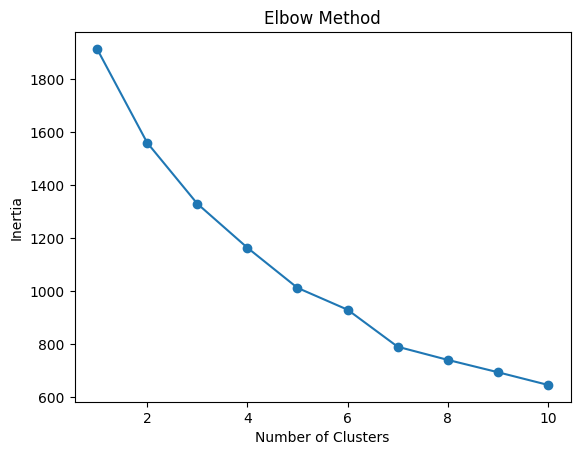

In [ ]:


# Elbow method to find optimal clusters
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(cluster_features_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()


In [ ]:
# Apply K-Means with optimal clusters (e.g., 4)
kmeans = KMeans(n_clusters=4, random_state=42)
data['cluster'] = kmeans.fit_predict(cluster_features_scaled)

# Display cluster centers
print("Cluster Centers:")
print(kmeans.cluster_centers_)


Cluster Centers:
[[ 0.4006507   0.25904415  0.06299857 -0.80440871  0.90300756]
 [ 0.28152862  0.28922197  0.16835927 -0.38810447 -0.9653175 ]
 [-1.3618751  -1.29587646 -1.12670614 -0.2416468  -0.07264215]
 [ 0.02255542  0.09611559  0.29892061  1.15530318  0.32456377]]


In [ ]:
# Select features for logistic regression
# Assuming 'cluster' as target, convert categorical features
X = pd.get_dummies(data[['age', 'max_altitude', 'annualincome', 'frequentflyer', 'evertravelledabroad']], drop_first=True)
y = data['cluster']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:


# Train logistic regression model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Make predictions
y_pred = log_reg.predict(X_test)

# Evaluate model
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy Score: 0.7142857142857143

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.70      0.78        23
           1       0.85      0.92      0.88        25
           2       1.00      0.23      0.38        13
           3       0.45      0.81      0.58        16

    accuracy                           0.71        77
   macro avg       0.80      0.66      0.65        77
weighted avg       0.80      0.71      0.70        77



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


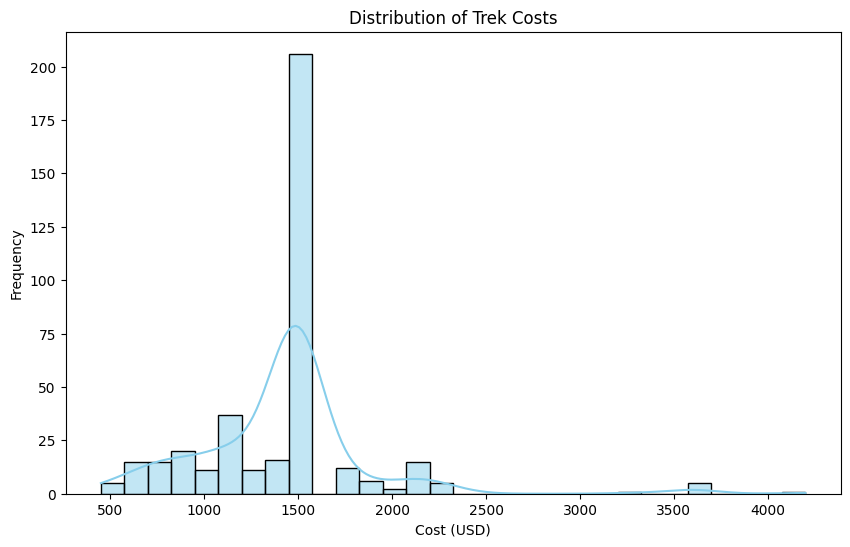

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data['cost'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Trek Costs')
plt.xlabel('Cost (USD)')
plt.ylabel('Frequency')
plt.show()


<ipython-input-54-585e1d9fae40>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='trip_grade', y='cost', palette='viridis')


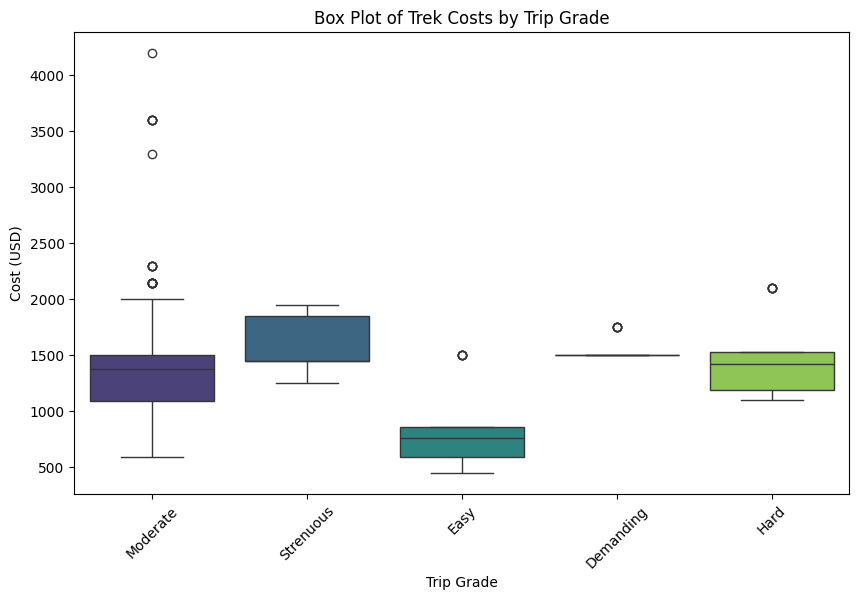

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='trip_grade', y='cost', palette='viridis')
plt.title('Box Plot of Trek Costs by Trip Grade')
plt.xlabel('Trip Grade')
plt.ylabel('Cost (USD)')
plt.xticks(rotation=45)
plt.show()


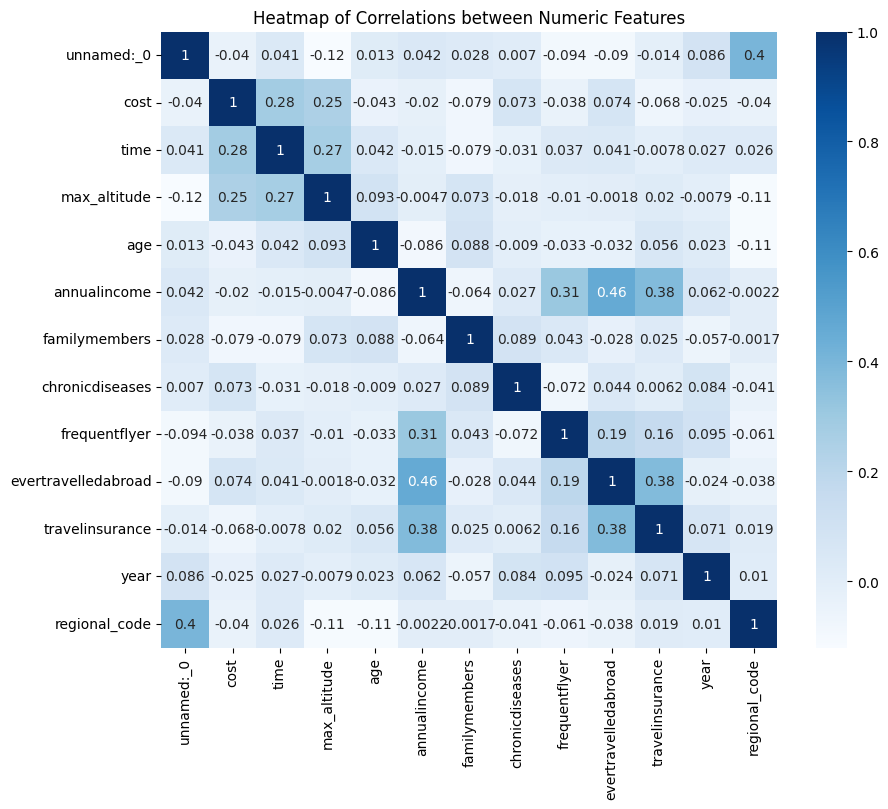

In [ ]:
# Selecting numeric columns for the correlation heatmap
numeric_features = data.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(10, 8))
correlation_matrix = numeric_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', square=True)
plt.title('Heatmap of Correlations between Numeric Features')
plt.show()


In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data['trip_grade'], palette='viridis')
plt.title('Count of Treks by Trip Grade')
plt.xlabel('Trip Grade')
plt.ylabel('Number of Treks')
plt.xticks(rotation=45)
plt.show()


<ipython-input-40-bdaecafd2dd6>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='accomodation', data=data, palette='magma')


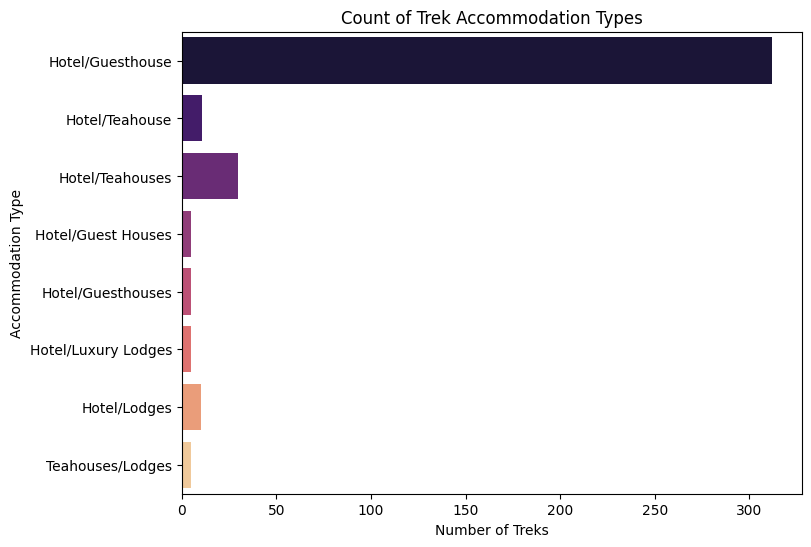

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(y='accomodation', data=data, palette='magma')
plt.title('Count of Trek Accommodation Types')
plt.xlabel('Number of Treks')
plt.ylabel('Accommodation Type')
plt.show()


In [ ]:

# Pair plot for selected features
sns.pairplot(data[['cost', 'time', 'max_altitude', 'age', 'annualincome']], diag_kind='kde')
plt.title('Pair Plot of Selected Features')
plt.show()


<ipython-input-60-c80e0fdfce2c>:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data.resample('M')['cost'].mean().plot()


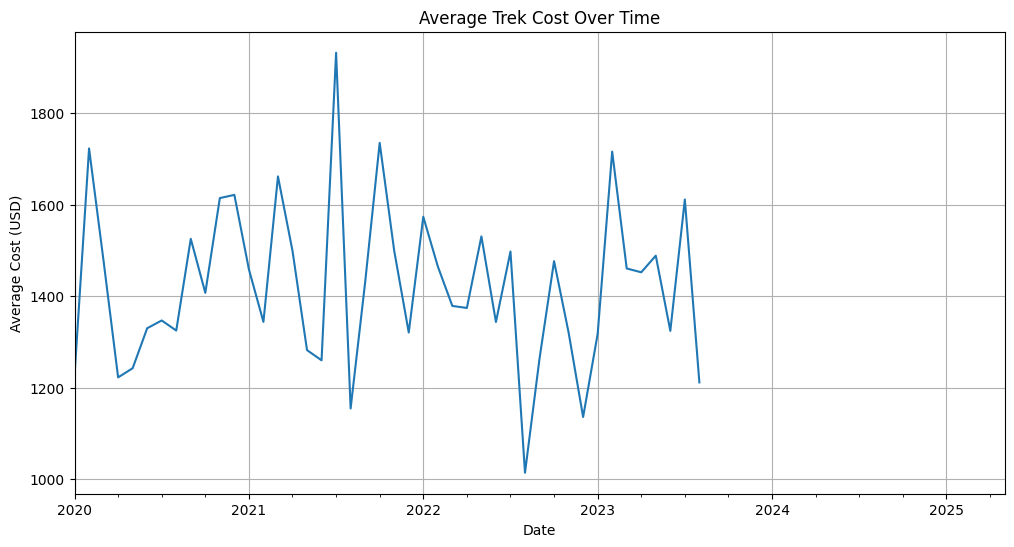

In [ ]:
#Time Series Plot
# Assuming there's a 'date_of_travel' column
data['date_of_travel'] = pd.to_datetime(data['date_of_travel'])
data.set_index('date_of_travel', inplace=True)

plt.figure(figsize=(12, 6))
data.resample('M')['cost'].mean().plot()
plt.title('Average Trek Cost Over Time')
plt.xlabel('Date')
plt.ylabel('Average Cost (USD)')
plt.grid()
plt.show()


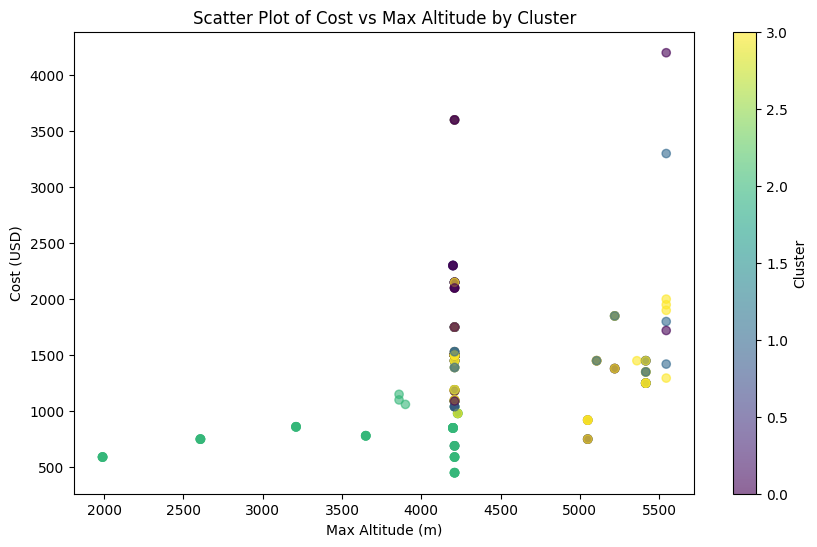

In [ ]:
#Scatter Plot with Clusters
plt.figure(figsize=(10, 6))
plt.scatter(data['max_altitude'], data['cost'], c=data['cluster'], cmap='viridis', alpha=0.6)
plt.title('Scatter Plot of Cost vs Max Altitude by Cluster')
plt.xlabel('Max Altitude (m)')
plt.ylabel('Cost (USD)')
plt.colorbar(label='Cluster')
plt.show()


<ipython-input-63-4a665aa56b8e>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='trip_grade', y='cost', palette='muted')


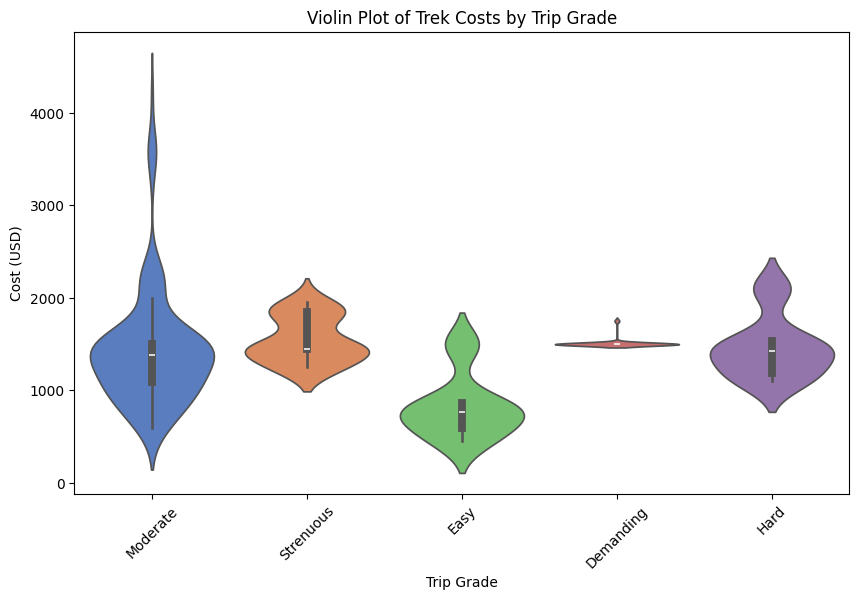

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=data, x='trip_grade', y='cost', palette='muted')
plt.title('Violin Plot of Trek Costs by Trip Grade')
plt.xlabel('Trip Grade')
plt.ylabel('Cost (USD)')
plt.xticks(rotation=45)
plt.show()
